# 2.3.1: Apparel Classification — MobileNetV2

In [2]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, BatchNormalization, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

## Load & Preprocess Images

In [3]:
IMG_SIZE = 224
DATA_DIR = 'data/apparel/dataset'
classes = sorted(os.listdir(DATA_DIR))
print(f'Classes: {classes}')

images = []
labels = []

for idx, cls in enumerate(classes):
    cls_dir = os.path.join(DATA_DIR, cls)
    for fname in os.listdir(cls_dir):
        fpath = os.path.join(cls_dir, fname)
        img = cv2.imread(fpath)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        images.append(img)
        labels.append(idx)

X = np.array(images, dtype='float32') / 255.0
y = np.array(labels)
print(f'Total images: {X.shape[0]}, Shape: {X.shape}')
print(f'Label distribution: {dict(zip(*np.unique(y, return_counts=True)))}')

Classes: ['dress', 'pants', 'shirt', 'shoes']
Total images: 800, Shape: (800, 224, 224, 3)
Label distribution: {np.int64(0): np.int64(200), np.int64(1): np.int64(200), np.int64(2): np.int64(200), np.int64(3): np.int64(200)}


## Train/Val/Test Split (80/10/10)

In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f'Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}')

Train: 640, Val: 80, Test: 80


## Build Model

In [5]:
base_model = MobileNetV2(include_top=False, weights='imagenet', input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(classes), activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,588 (9.26 MB)

 Trainable params: 167,044 (652.52 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

## Train

In [6]:
early_stop = EarlyStopping(patience=2, monitor='val_loss', restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 600ms/step - accuracy: 0.8172 - loss: 0.5164 - val_accuracy: 0.8750 - val_loss: 0.3371
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 537ms/step - accuracy: 0.9750 - loss: 0.0830 - val_accuracy: 0.9000 - val_loss: 0.2821
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 544ms/step - accuracy: 0.9844 - loss: 0.0408 - val_accuracy: 0.9000 - val_loss: 0.2578
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 550ms/step - accuracy: 0.9937 - loss: 0.0328 - val_accuracy: 0.9000 - val_loss: 0.2405
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 515ms/step - accuracy: 0.9953 - loss: 0.0137 - val_accuracy: 0.9125 - val_loss: 0.2231
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 495ms/step - accuracy: 0.9984 - loss: 0.0080 - val_accuracy: 0.9250 - val_loss: 0.2227
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 555ms/step - accuracy: 0.9953 - loss: 0.0116 - val_accuracy: 0.9375 - val_loss: 0.2133
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 505ms/step - accuracy: 0.9969 - loss: 0.0095 - val_accu

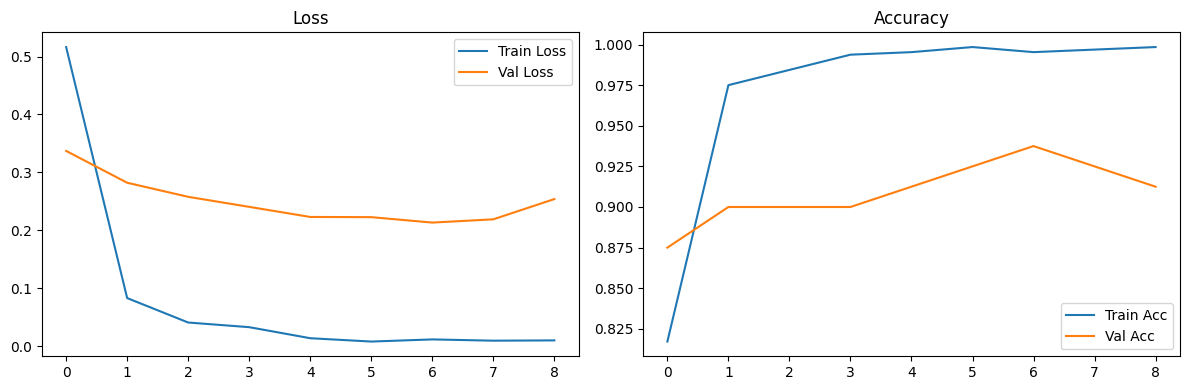

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

## Evaluation

In [8]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}')

y_pred = np.argmax(model.predict(X_test), axis=1)
print()
print(classification_report(y_test, y_pred, target_names=classes))

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 324ms/step - accuracy: 0.9625 - loss: 0.0948
Test Loss: 0.0948, Test Accuracy: 0.9625
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 697ms/step

              precision    recall  f1-score   support

       dress       0.95      1.00      0.98        20
       pants       0.95      0.95      0.95        20
       shirt       1.00      0.90      0.95        20
       shoes       0.95      1.00      0.98        20

    accuracy                           0.96        80
   macro avg       0.96      0.96      0.96        80
weighted avg       0.96      0.96      0.96        80



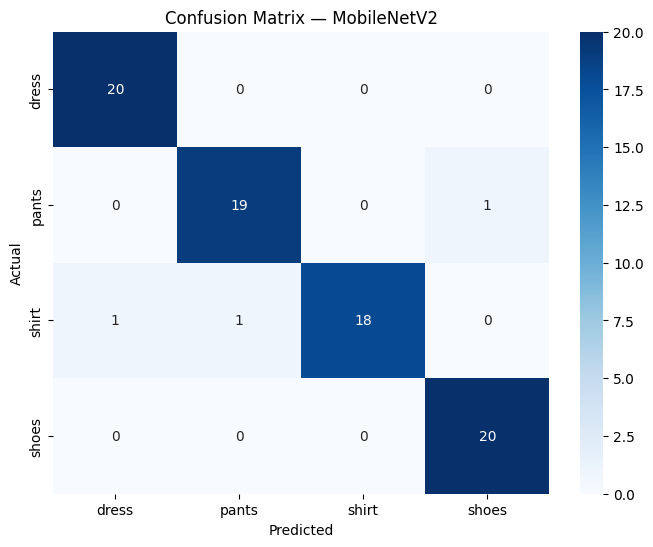

In [9]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — MobileNetV2')
plt.show()